<a href="https://colab.research.google.com/github/hectorjimenez12/CC5205_Proyecto/blob/main/Game_ClassificationCNNV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento 3 Proyecto Mineria de datos

In [1]:
import pandas as pd
import numpy as np
import random
import torch
from torch.utils.data import TensorDataset, DataLoader
from PIL import Image
from torchvision import datasets, models, transforms
import time
import copy

import json
import ast

seed =  3495 #5937261 #  #123456

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True


# Cargar datos y descargar imagenes utilizadas

In [2]:
#url = 'https://raw.githubusercontent.com/hectorjimenez12/Mineria_Datos/main/steam.csv'
#dfdata = pd.read_csv(url)
#url = 'https://raw.githubusercontent.com/hectorjimenez12/Mineria_Datos/main/steam_description_data.csv.zip'
#df_descriptions = pd.read_csv(url)
#url = 'https://raw.githubusercontent.com/hectorjimenez12/Mineria_Datos/main/steam_media_data.csv.zip'
url = 'https://raw.githubusercontent.com/hectorjimenez12/Mineria_Datos/main/SteamSpy_Filt_AllData.zip'
dfmedia = pd.read_csv(url)

In [3]:
dfmedia

,index,appid,name,owners,screenshots,priceclp
0,1,4720,Condemned: Criminal Origins,200000-500000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",7500.0
1,2,7800,Stubbs the Zombie in Rebel Without a Pulse,200000-500000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",10500.0
2,4,10270,Disciples III: Reincarnation,100000-200000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",2875.0
3,6,11550,Second Sight,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",5500.0
4,7,12210,Grand Theft Auto IV: The Complete Edition,5000000-10000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",14990.0
...,...,...,...,...,...,...
21215,26497,2559280,Drift Cars Zombie Crusher,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",434.0
21216,26498,2559980,I commissioned some ladybugs 2,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",2040.0
21217,26499,2561180,Rescue Team: Mineral of Miracles,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",3570.0
21218,26500,2562650,Agriculture Tractor Sim,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",871.0


In [4]:
#dfdata.groupby('owners').count().loc[:,'name'].sort_values().plot.bar()
#ELIMINAR LOS DE CLASE entre 100000 y 200000

dfmedia = dfmedia[~ dfmedia.owners.isin(['100000-200000']) ]
dfmedia = dfmedia.reset_index(level=0,drop=True)
dfmedia

,index,appid,name,owners,screenshots,priceclp
0,1,4720,Condemned: Criminal Origins,200000-500000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",7500.0
1,2,7800,Stubbs the Zombie in Rebel Without a Pulse,200000-500000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",10500.0
2,6,11550,Second Sight,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",5500.0
3,7,12210,Grand Theft Auto IV: The Complete Edition,5000000-10000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",14990.0
4,8,16900,GROUND BRANCH,1000000-2000000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",15500.0
...,...,...,...,...,...,...
20106,26497,2559280,Drift Cars Zombie Crusher,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",434.0
20107,26498,2559980,I commissioned some ladybugs 2,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",2040.0
20108,26499,2561180,Rescue Team: Mineral of Miracles,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",3570.0
20109,26500,2562650,Agriculture Tractor Sim,0-20000,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam...",871.0


In [5]:
def class_owners(strowners):
  own_int = int(strowners.split('-')[0])
  if own_int > 100000:
    return 'Hsell'
  else:
    return 'Lsell'
class_owners(dfmedia.owners[2])

'Lsell'

In [6]:
from google.colab import drive
drive.mount('/content/gdrive')
import os


Mounted at /content/gdrive


Cambiar esto

In [7]:
ids = os.listdir('/content/gdrive/MyDrive/U/S1/Mineria_Datos/Proyecto/Hito3/imagenes')
ids = [ int(i.split('.')[0].split('header')[1]) if i[0:3] != 'add' else int(i.split('.')[0].split('add')[1]) for i in ids]
dfmedia = dfmedia[dfmedia.appid.isin(ids)]
#Image.open('/content/gdrive/MyDrive/U/S1/Mineria_Datos/Proyecto/Hito3/imagenes/add1046110.png')

<ipython-input-8-754c17ace6ee>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfmedia['owners_label'] = [ class_owners(i) for i in dfmedia.owners ]


<Axes: xlabel='owners_label'>

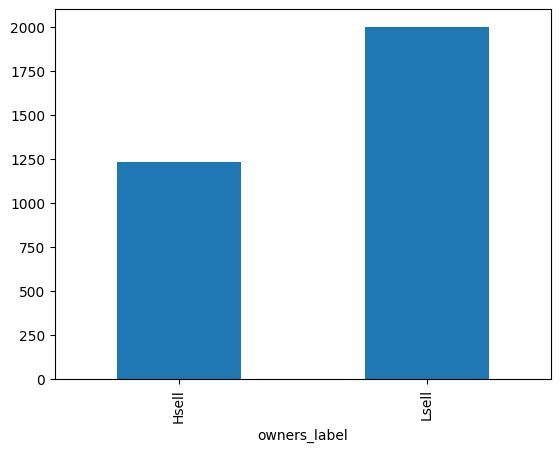

In [8]:
dfmedia['owners_label'] = [ class_owners(i) for i in dfmedia.owners ]
dfmedia.groupby('owners_label').count().loc[:,'name'].plot.bar()

Seleccionamos un sample de 500 por cada clase

In [9]:
Nsample  = 600
labels   = ['Hsell','Lsell']
list_ids = [ random.sample(list(dfmedia.index[dfmedia.owners_label.isin([i])]),k=Nsample) for i in labels ]
dfsample = dfmedia.loc[ sum(list_ids,[]) , ['appid','name','owners','owners_label','priceclp','screenshots'] ]
dfsample

,appid,name,owners,owners_label,priceclp,screenshots
3715,684450,Surviving the Aftermath,200000-500000,Hsell,28100.63,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
69,205230,Hell Yeah! Wrath of the Dead Rabbit,1000000-2000000,Hsell,7500.00,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
1101,367450,Poly Bridge,1000000-2000000,Hsell,1760.00,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
11479,1410710,Democracy 4,200000-500000,Hsell,4184.00,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
1605,420740,The Deed,200000-500000,Hsell,620.00,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
...,...,...,...,...,...,...
2224,487020,Fantasy Mosaics 14: Fourth Color,0-20000,Lsell,990.00,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
2393,499340,Turner,0-20000,Lsell,1500.00,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
15549,1851470,Ikkarus and the Prince of Sin,0-20000,Lsell,5750.00,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."
1515,411130,Leviathan: the Cargo — Ongoing series,0-20000,Lsell,1000.00,"[{'id': 0, 'path_thumbnail': 'https://cdn.akam..."


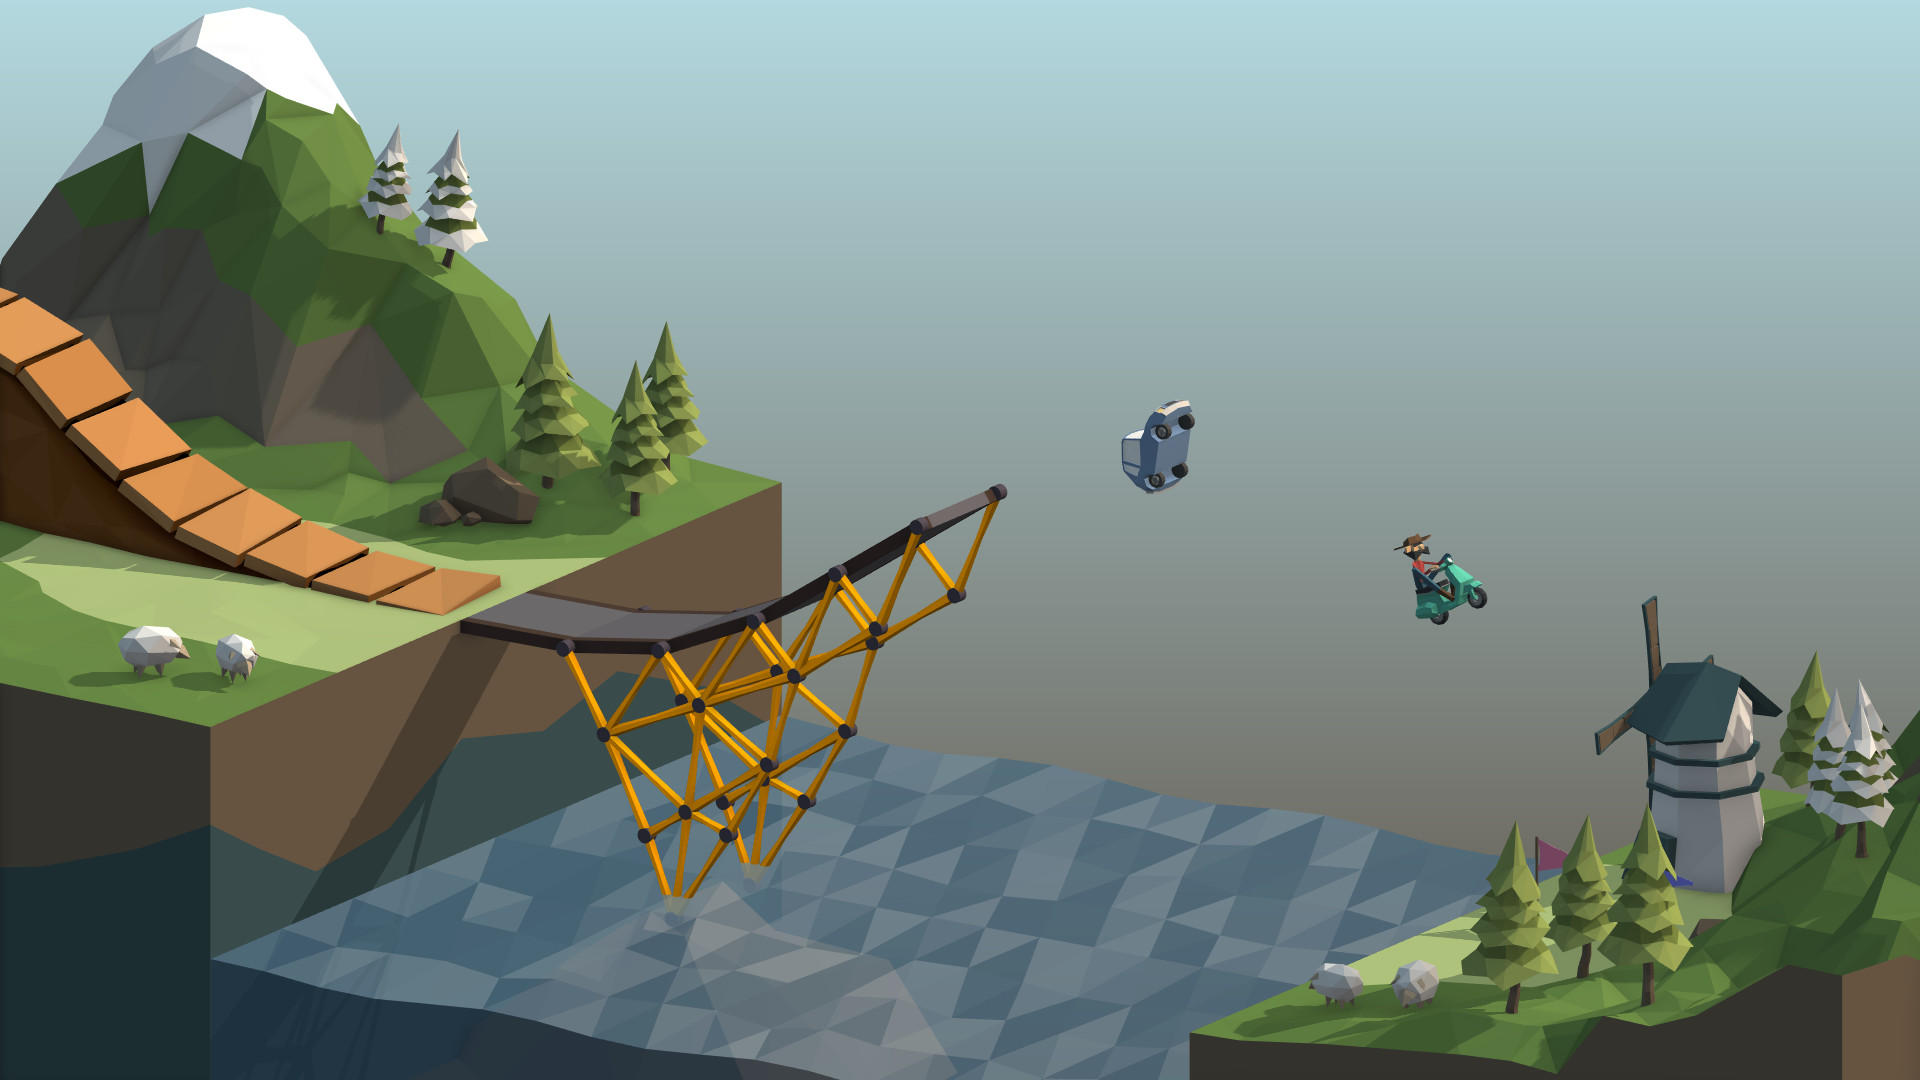

In [10]:
Image.open('/content/gdrive/MyDrive/U/S1/Mineria_Datos/Proyecto/Hito3/imagenes/add'+str(dfsample.appid.iloc[2])+'.png')

In [11]:
#list_img = []
#for i in dfsample.appid:
#  #screenshots  = df_media['screenshots'][df_media.steam_appid.isin([i])]
#  screenshots  = dfsample['screenshots'][dfsample.appid.isin([i])]
#  screenshots2 = screenshots.iloc[0][1:-1]
#  screenshots3 = screenshots2.split('},')
#  screen_ds = [ast.literal_eval(idict+'}') if idict[-1] != '}' else ast.literal_eval(idict) for idict in screenshots3 ]

#  aditional_image = random.sample(screen_ds,1)
#  !wget -O 'add.png' {aditional_image[0]['path_full']}
#  !wget https://cdn.cloudflare.steamstatic.com/steam/apps/{i}/header.jpg
#  add_im = Image.open('add.png')
#  list_img.append( [ Image.open('header.jpg') ,copy.deepcopy(add_im)] )
#  !rm header.jpg
#  #!rm add.png

#list_img[20]

# 1 Definicion de clases y transformaciones


In [54]:
import torchvision
class GamesDataset(torch.utils.data.Dataset):
  def __init__(self,root , appids, prices, labels, transform):
    self.transform = transform
    self.root = root
    self.class2idx = dict()
    self.class2idx['Lsell'] = 0
    self.class2idx['Hsell'] = 1
    self.classes = ['Lsell','Hsell']
    self.labels = labels
    self.prices = prices

    self.header_images = []
    self.add_images  = []

    for id_image in appids:
      self.header_images.append(self.root + 'header'  + str(id_image) +'.jpg')
      self.add_images.append(self.root + 'add'  + str(id_image) +'.png')

  def __len__(self):
    return len(self.header_images)

  def __getitem__(self, idx):
    header = Image.open( self.header_images[idx] ).convert('RGB')
    add = Image.open( self.add_images[idx] ).convert('RGB')
    label = self.class2idx[self.labels[idx]]

    if self.transform:
      header = self.transform(header)
      add    = self.transform(add)

    return header, add, torch.tensor(self.prices[idx],dtype = torch.float32 ), label

In [55]:
transforms = torchvision.transforms.Compose([torchvision.transforms.Resize(100),
                                             torchvision.transforms.CenterCrop(160),
                                             torchvision.transforms.ToTensor() ] )
#torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
#list_img = [i[1] for i in list_img]

Split dataset en train, validation y test

In [56]:
from sklearn.model_selection import train_test_split
ylabel = list(dfsample['owners_label'])
appids_prices = np.array(dfsample.loc[:,['appid','priceclp']])
X_train, X_test, Y_train, Y_test = train_test_split( appids_prices , ylabel, test_size = 0.1, stratify = ylabel , random_state=seed)
X_train, X_val , Y_train, Y_val  = train_test_split(X_train, Y_train, test_size=10/90, stratify= Y_train, random_state=seed)

In [15]:
#ipos = 556
#print(dfsample.iloc[ipos])
#print(ylabel[ipos])
#list_img[ipos][0]

In [57]:
# crear Games datasets
train_dataset = GamesDataset(root='/content/gdrive/MyDrive/U/S1/Mineria_Datos/Proyecto/Hito3/imagenes/',
                             appids = X_train[:,0].astype(int) , prices= X_train[:,1].astype(int),
                             labels = Y_train , transform = transforms)
valid_dataset = GamesDataset(root='/content/gdrive/MyDrive/U/S1/Mineria_Datos/Proyecto/Hito3/imagenes/',
                             appids = X_val[:,0].astype(int) , prices= X_val[:,1].astype(int),
                             labels = Y_val , transform = transforms)
test_dataset  = GamesDataset(root='/content/gdrive/MyDrive/U/S1/Mineria_Datos/Proyecto/Hito3/imagenes/',
                             appids = X_test[:,0].astype(int) , prices= X_test[:,1].astype(int),
                             labels = Y_test , transform = transforms)
# dataloaders
batch_size = 20

train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
valid_loader = DataLoader(valid_dataset, shuffle=True, batch_size=batch_size)
test_loader  = DataLoader(test_dataset, shuffle=False, batch_size=1)

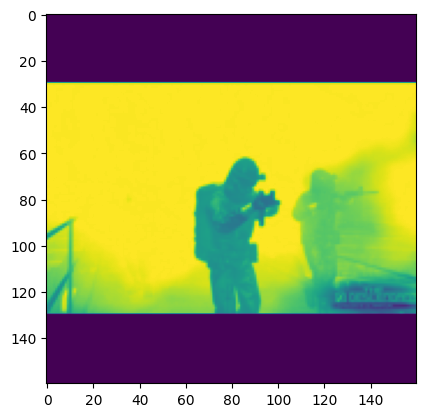

In [58]:
import matplotlib.pyplot as plt
for header, add, price, test_labels in train_loader:
    sample_header = header[1]    # Reshape them according to your needs.
    sample_add = add[1]

#sample_image.shape
plt.imshow(sample_header.to('cpu').numpy()[2,:,:])
plt.imshow(sample_add.to('cpu').numpy()[2,:,:])

In [59]:
train_on_gpu=torch.cuda.is_available()
if(train_on_gpu):
    print('Training on GPU.')
else:
    print('No GPU available, training on CPU.')

Training on GPU.


In [60]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# 3. CNN neural model

Basic convolution

In [61]:
import torchsummary as ts
from torch.nn import Module, Sequential, LeakyReLU, Conv2d, BatchNorm2d, AvgPool2d, MaxPool2d, AdaptiveAvgPool2d, Linear
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
num_epochs = 10
momentum = 0.9
log_interval = 100
learning_rate=0.001

In [62]:
class MLP(nn.Module):
  def __init__(self, input_dim, output_dim,dlayers):
    super().__init__()
    self.nlayers = 2
    self.fc1 = nn.Linear(input_dim, list(dlayers.items())[0][1].weight.shape[1] ) #capa de entrada
    for iname,hlayer in dlayers.items(): # capas ocultas
      setattr(self,iname,hlayer)
      self.nlayers = self.nlayers+ 1
    setattr(self,'fc'+str(self.nlayers),nn.Linear(hlayer.weight.shape[0], output_dim)) # salida a funcion de activacion
  def forward(self, input):
    batch_size = input.shape[0]
    input = input.view(batch_size, -1)
    #print(input)
    next_input = F.relu(self.fc1(input))
    for ilayer in range(self.nlayers - 2):
      next_input = F.relu( getattr(self,'fc'+str(ilayer+2))(next_input) )
    y_pred =  getattr(self,'fc'+str(self.nlayers))(next_input)
    #print(y_pred)
    return y_pred

MLP_model = MLP(input_dim = 1 , output_dim = 5,dlayers={'fc2':nn.Linear(50, 25)})
#MLP_model(input = torch.tensor([7],dtype = torch.float32 ))
print(MLP_model)
ts.summary(MLP_model.to(device), (1,1,1), device='cuda') #-1 representa el tamaño de batch


MLP(
  (fc1): Linear(in_features=1, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=25, bias=True)
  (fc3): Linear(in_features=25, out_features=5, bias=True)
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 50]             100
            Linear-2                   [-1, 25]           1,275
            Linear-3                    [-1, 5]             130
Total params: 1,505
Trainable params: 1,505
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01
----------------------------------------------------------------


In [74]:
class BasicConv2d(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, **kwargs) -> None:
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 16, kernel_size=3,padding = 1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3,padding = 1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, out_channels, kernel_size=3)
        self.bn3 = nn.BatchNorm2d(out_channels)
    def forward(self, x):
        x = F.relu(F.max_pool2d(self.bn1(self.conv1(x)) , 2) )
        x = F.relu( F.max_pool2d(self.bn2(self.conv2(x)) , 2) )
        return F.relu( self.bn3(self.conv3(x)) )

In [78]:
class Net(nn.Module):
  def __init__(self):
    super(Net,self).__init__()
    self.branch_header = BasicConv2d(3, 64, kernel_size=3, stride=1, padding=1)  # 160 --> 80 --> 40
    self.branch_add    = BasicConv2d(3, 64, kernel_size=3, stride=1, padding=1)  # 64 channels
    self.branch_price  = MLP(input_dim = 1 , output_dim = 5,dlayers={'fc2':nn.Linear(50, 25)}) #FCL
    self.fc1 = nn.Linear( 38*38*64*2 + 5 , 100) #"256"
    self.fc2 = nn.Linear(100,1)
    self.sig = nn.Sigmoid()
  def forward(self, im1,im2,p):
    # header --> -1, 224/2 x 224/2 x 64, add--> -1, 224/2 x 224/2 x 64, price --> -1, 10
    outputs              = [self.branch_header(im1), self.branch_add(im2), self.branch_price(p)]
    #for i,out in enumerate(outputs):
    #  print(out.shape)
    #flattening and concat
    outputs[0] = outputs[0].view(-1, 38*38*64 )
    outputs[1] = outputs[1].view(-1, 38*38*64 )
    embedd_cat = torch.cat(outputs, 1) #
    #output = embedd_cat.view(-1, 10 )
    x = F.relu(self.fc1(embedd_cat))
    x = self.fc2(x)
    return self.sig(x)

network = Net()
criterion = nn.BCELoss()
optimizer = torch.optim.Adam( network.parameters(), lr=learning_rate)

In [79]:
#https://pypi.org/project/torch-summary/
print(network)
ts.summary(network.to(device), [(3, 160, 160),(3, 160, 160),(1,1,1)] , device='cuda') #-1 representa el tamaño de batch

Net(
  (branch_header): BasicConv2d(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (branch_add): BasicConv2d(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (bn3): BatchNorm2d(64, eps=1e-0

In [80]:
def accuracy(y_pred,y_real):
  y_pred = np.round(y_pred)
  corrects = 0
  for i,y in enumerate(y_pred):
    if y == y_real[i]:
      corrects +=1
  return float(corrects/len(y_pred))

accuracy(torch.Tensor([0.8,0,0.7,0.9]),[1,0,1,1])

1.0

In [85]:
train_losses = []
train_counter = []
test_losses = []
validation_losses = []

clip=5

test_counter = [i*len(train_loader.dataset) for i in range(num_epochs+1)]

#Function to train one epoch
def train(network, optimizer,  epoch):
  network.train() #Modo entrenamiento
  for batchId, (data1,data2,data3,target) in enumerate(train_loader): #Iterate over batches
    data1 = data1.to(device)
    data2 = data2.to(device)
    data3 = data3.to(device)
    target = target.to(device)

    #Feedforward pass
    optimizer.zero_grad()
    output = network(data1,data2,data3)

    loss = criterion(output.squeeze(), target.float() )
    loss.backward()
    nn.utils.clip_grad_norm_(network.parameters(), clip)
    optimizer.step()

    out_arr = output.cpu().data.numpy()
    if batchId % log_interval == 0:
      print('Train epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(epoch, batchId*len(data1), len(train_loader.dataset), 100.*batchId/len(train_loader), loss.item()))
      train_losses.append(loss.item())
      train_counter.append((batchId*64) + ((epoch-1)*len(train_loader.dataset)))
      torch.save(network.state_dict(),'model.pth')
      torch.save(optimizer.state_dict(), 'optimizer.pth')

#Validation
def validation(network):
  network.eval() #Test mode
  validation_loss = 0
  correct = 0
  with torch.no_grad():
    for data, target in valid_loader:
      data = data.to(device)
      target = target.to(device)
      output = network(data)
      validation_loss += F.nll_loss(output, target, size_average=False).item()
      pred = output.data.max(1, keepdim=True)[1]
      correct += pred.eq(target.data.view_as(pred)).sum()
  length = len(valid_loader.dataset)
  validation_loss /= length
  validation_losses.append(validation_loss)
  print('\nValidation set: Avg. Loss: {:.4f}, Accuracy: {}/{} ({:.0f}%), Error: {:.3f}% \n'.format(validation_loss, correct, len(valid_loader.dataset), 100.*correct/len(valid_loader.dataset), 100.*(length-correct)/length))


#Testing
def test(network):
  network.eval() #Test mode

  test_losses = [] # track loss
  correct = 0

  with torch.no_grad():
    for batchId, (data1,data2,data3,target)  in enumerate(test_loader):
      data1 = data1.to(device)
      data2 = data2.to(device)
      data3 = data3.to(device)
      target = target.to(device)
      output = network(data1,data2,data3)

      test_loss = criterion(output.view(-1).float() , target.float() )
      test_losses.append(test_loss.item())

      pred = torch.round(output.squeeze())

      correct += pred.eq(target.data.view_as(pred)).sum()

      #correct_tensor = pred.eq(labels.float().view_as(pred))
      #correct = np.squeeze(correct_tensor.numpy()) if not train_on_gpu else np.squeeze(correct_tensor.cpu().numpy())
      #num_correct += np.sum(correct)

  length = len(test_loader.dataset)
  test_loss /= length
  test_losses.append(test_loss)
  print('\nTest set: Avg. Loss: {:.4f}, Accuracy: {}/{} ({:.0f}%), Error: {:.3f}% \n'.format(test_loss, correct, len(test_loader.dataset), 100.*correct/len(test_loader.dataset), 100.*(length-correct)/length))

In [ ]:
for batchId, (data1,data2,data3,target)  in enumerate(test_loader):
  print(batchId)
  target.data


tensor([1])

In [86]:
test(network)
for epoch in range(1, num_epochs + 1):
  train(network, optimizer, epoch)
  #validation(network)
  test(network)



Test set: Avg. Loss: 0.0006, Accuracy: 70/120 (58%), Error: 41.667% 

0.0
Train epoch: 1 [0/960 (0%)]	Loss: 18.879324
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0

Test set: Avg. Loss: 0.8333, Accuracy: 60/120 (50%), Error: 50.000% 

0.0
Train epoch: 2 [0/960 (0%)]	Loss: 50.000000
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0

Test set: Avg. Loss: 0.8333, Accuracy: 68/120 (57%), Error: 43.333% 

0.0
Train epoch: 3 [0/960 (0%)]	Loss: 26.793638
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0

Test set: Avg. Loss: 0.8333, Accuracy: 62/120 (52%), Error: 48.333% 

0.0
Trai

--------------------------------------------------------------------------------------------

In [ ]:
def train_model(model,criterio,optimizer,scheduler,train_loader,train_data,val_loader,val_data,num_epochs = 100):
  since = time.time()
  best_model_wts = copy.deepcopy(model.state_dict())
  best_acc = 0.0
  best_acc_train = 0.0
  best_acc_val = 0.0
  for epoch in range(num_epochs):
    print('Epoch {}/{}'.format(epoch, num_epochs-1))
    #print('-' * 10)
    #Train model
    scheduler.step()
    model.train()
    running_loss = 0.0
    running_corrects = 0.0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
    epoch_loss = running_loss /len(train_data)
    epoch_acc_train = running_corrects.double() / len(train_data)
    print('Train Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc_train))
    #Validation
    model.eval()
    running_loss = 0.0
    running_corrects = 0.0
    for inputs, labels in val_loader:
      inputs = inputs.to(device)
      labels = labels.to(device)
      with torch.set_grad_enabled(False):
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
      running_loss += loss.item() * inputs.size(0)
      running_corrects += torch.sum(preds == labels.data)
    epoch_loss = running_loss /len(val_data)
    epoch_acc = running_corrects.double() / len(val_data)
    print('Val Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc))
    if epoch_acc > best_acc:
        best_acc_train = epoch_acc_train
        best_acc = epoch_acc
        best_acc_val = epoch_acc
        best_model_wts = copy.deepcopy(model.state_dict())
    if float(epoch_acc_train) - float(epoch_acc)  > 0.3:
      print('early stopping at epoch ',epoch)
      print(epoch_acc_train)
      print(epoch_acc)
      break
  time_elapsed = time.time() - since
  print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed//60, time_elapsed % 60))
  print('Best val accucary: {:.4f}'.format(best_acc))
  print('Best train accucary: {:.4f}'.format(best_acc_train))
  print('--------------------------------------')
  print('--------------------------------------')
  print('--------------------------------------')
  model.load_state_dict(best_model_wts)
  return model,best_acc_train,best_acc_val

In [ ]:
def predict_test(model,test_data):
    #Test
    model.eval()
    running_corrects = 0.0
    for inputs, labels in test_loader:
      inputs = inputs.to(device)
      labels = labels.to(device)

      with torch.set_grad_enabled(False):
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        #print(outputs)

      running_corrects += torch.sum(preds == labels.data)
      #print(running_corrects)

    acc_test = running_corrects.double() / len(test_data)
    return acc_test

In [ ]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
rs= models.resnet18(pretrained=True)

In [ ]:
pretrained = copy.deepcopy(rs)
nweights = 1000
pretrained.classifier = nn.Sequential(nn.Linear(512 * 7 * 7, nweights),
                            nn.ReLU(True),
                            nn.BatchNorm1d(nweights),
                            nn.Dropout(p=0.8),
                            nn.Linear(nweights, nweights),
                            nn.ReLU(True),
                            nn.BatchNorm1d(nweights),
                            nn.Dropout(p=0.8),
                            nn.Linear(nweights, 2),)
pretrained = pretrained.to(device)
criterion = nn.CrossEntropyLoss()
#optimizer = torch.optim.SGD( pretrained.parameters(),lr = 0.001,momentum = 0.8 )
optimizer = torch.optim.Adam(pretrained.parameters(), lr=0.001) #, momentum=0.9
exp_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
trained, tacc,vacc = train_model(pretrained, criterion, optimizer, exp_lr_scheduler,
                                 train_loader = train_loader, train_data= train_dataset,
                                 val_loader = valid_loader, val_data=valid_dataset, num_epochs = 10)
testacc = predict_test(model = trained, test_data = test_dataset)


Freezing

In [ ]:
rs = models.vgg19(pretrained = True)

In [ ]:
pretrained = copy.deepcopy(rs)

for param in pretrained.parameters():
    param.requires_grad = False

nweights = 4000
pretrained.classifier = nn.Sequential(nn.Linear(512 * 7 * 7, nweights),
                            nn.ReLU(True),
                            nn.BatchNorm1d(nweights),
                            nn.Dropout(p=0.5),
                            nn.Linear(nweights, nweights),
                            nn.ReLU(True),
                            nn.BatchNorm1d(nweights),
                            nn.Dropout(p=0.5),
                            nn.Linear(nweights, 2),)
pretrained = pretrained.to(device)
criterion = nn.CrossEntropyLoss()
#optimizer = torch.optim.SGD( pretrained.parameters(),lr = 0.001,momentum = 0.8 )
optimizer = torch.optim.Adam(pretrained.classifier.parameters(), lr=0.001) #, momentum=0.9
exp_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
trained, tacc,vacc = train_model(pretrained, criterion, optimizer, exp_lr_scheduler,
                                 train_loader = train_loader, train_data= train_dataset,
                                 val_loader = valid_loader, val_data=valid_dataset, num_epochs = 10)
testacc = predict_test(model = trained, test_data = test_dataset)

